In [119]:
import os,sys
import numpy as np
import configparser
import matplotlib.pyplot as plt
import matplotlib
import argparse
from psana import DataSource
from numba import jit, njit
import scipy.ndimage.measurements as smt
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *
from UEDePixTools import *
from tqdm import tqdm
from PIL import Image
from matplotlib.colors import LogNorm
# %matplotlib widget

In [120]:
# exp and run infor and load raw data using LCLS DataSource
exp = 'ued1015999'  # experiment
run = 115 # charge scan of Al on the 
# max_events = num_steps*1080 # how many shots to load
max_events = 540*16 # how many shots to load
ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
# ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
myrun  = next(ds.runs()) # Load runs
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps') # Detector
evt    = next(myrun.events()) # event
steps  = myrun.steps() 

In [121]:
# Define some trial peak finding parameters
max_electrons = 1000 # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal
# delete the dataSource to obtain the new DataSource
try:
    ds  # Try to access the variable
    print("ds exists!")
    print("ds deleted!")
    del ds
except NameError:
    print("ds does not exist.")

ds exists!
ds deleted!


In [122]:
# Running the peak finding
beamCenter = np.array([397,309]) # set the center manually if needed
calib_evts     = [] # Modules of each evt
img_raw_evts   = [] # Raw images
x_evts         = [] # Peak X coordinates
y_evts         = [] # Peak Y coordinates
Intensity_evts = [] # Peak intensities
Size_evts      = [] # Peak pixel size
n_peaks_evts   = [] #
step_evts      = [] # Delay stage position

# --- NEW: choose the window of events you actually want ---
#start_event = 0   # first event to process, dense
start_event = 0   # first event to process, sparse
end_event   = start_event + 5000   # last event to process (exclusive)

# Load the data from xtc files
exp = 'ued1015999'  # experiment

#run = 115 # charge scan of Al on the
run = 125

# max_events must be high enough to REACH your window
ds     = DataSource(exp=exp, run=run, max_events=end_event) # only pull up to end_event
myrun  = next(ds.runs()) # Load runs
epix   = myrun.Detector('epixquad1kfps')

evt_count = 0 # Counter of the event
for evt in myrun.events():
    # --- NEW: skip the early events cheaply (no calib/blobCounter) ---
    if evt_count < start_event:
        evt_count += 1
        continue
    # --- NEW: stop once we pass the window ---
    if evt_count >= end_event:
        break

    calib = epix.raw.calib(evt)
    if calib is None: # this can return none, skip if it does
        evt_count += 1        # <-- keep counter consistent even on skips
        continue
    evt_count = evt_count + 1
    if evt_count % 100 == 0:
        print('Looking at evt # ' + str(evt_count))

    # define output arrays for peaks then populate them
    n_peaks = np.zeros(calib.shape[0])
    x = np.zeros((calib.shape[0], max_electrons))
    y = np.zeros((calib.shape[0], max_electrons))
    intensities = np.zeros((calib.shape[0], max_electrons))
    sizes = np.zeros((calib.shape[0], max_electrons))

    # The peakFinding algorithm
    for i, module in enumerate(calib): # loop the number of quadrants
        n, _x, _y, _ints, _sizes = blobCounter(module, threshold, min_signal)
        n_peaks[i] = n
        if n > max_electrons:
            x[i] = _x[:max_electrons]
            y[i] = _y[:max_electrons]
            intensities[i] = _ints[:max_electrons]
            sizes[i] = _sizes[:max_electrons]
        else:
            x[i][:n] = _x
            y[i][:n] = _y
            intensities[i][:n] = _ints
            sizes[i][:n] = _sizes
    step_evts.append(step_v(evt))
    calib_evts.append(calib)
    x_evts.append(x)
    y_evts.append(y)
    Intensity_evts.append(intensities)
    Size_evts.append(sizes)
    n_peaks_evts.append(n_peaks)
    img_raw_evts.append(epix.raw.image(evt,calib))

x_evts = np.array(x_evts)
y_evts = np.array(y_evts)
Intensity_evts = np.array(Intensity_evts)
Size_evts = np.array(Size_evts)
n_peaks_evts = np.array(n_peaks_evts)
step_evts = np.array(step_evts)
print(str(len(x_evts)) + ' evts processed (from window ' 
      + str(start_event) + ' to ' + str(end_event) + ')')
print('Finish peak finding')
print('Delays are:' + str(np.unique(step_evts)))

Looking at evt # 100
Looking at evt # 200
Looking at evt # 300
Looking at evt # 400
Looking at evt # 500
Looking at evt # 600
Looking at evt # 700
Looking at evt # 800
Looking at evt # 900
Looking at evt # 1000
Looking at evt # 1100
Looking at evt # 1200
Looking at evt # 1300
Looking at evt # 1400
Looking at evt # 1500
Looking at evt # 1600
Looking at evt # 1700
Looking at evt # 1800
Looking at evt # 1900
Looking at evt # 2000
Looking at evt # 2100
Looking at evt # 2200
Looking at evt # 2300
Looking at evt # 2400
Looking at evt # 2500
Looking at evt # 2600
Looking at evt # 2700
Looking at evt # 2800
Looking at evt # 2900
Looking at evt # 3000
Looking at evt # 3100
Looking at evt # 3200
Looking at evt # 3300
Looking at evt # 3400
Looking at evt # 3500
Looking at evt # 3600
Looking at evt # 3700
Looking at evt # 3800
Looking at evt # 3900
Looking at evt # 4000
Looking at evt # 4100
Looking at evt # 4200
Looking at evt # 4300
Looking at evt # 4400
Looking at evt # 4500
Looking at evt # 46

In [123]:
np.save('catalog/Intensity_evts_run_'+str(run)+'_pedestal.npy', Intensity_evts)

In [126]:
len(img_raw_evts)

5000

In [129]:
frame_stds = np.array([np.std((img[0].flatten())[img[0].flatten() != 0]) for img in img_raw_evts])

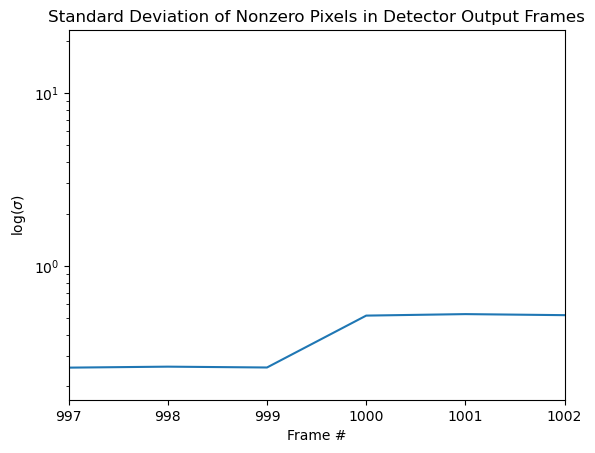

In [142]:
plt.plot(frame_stds)
plt.title("Standard Deviation of Nonzero Pixels in Detector Output Frames")
plt.ylabel("log($\sigma$)")
plt.xlabel("Frame #")
plt.xlim(997,1002)
plt.yscale('log')

In [158]:
avg_stds = np.array([np.mean(frame_stds[1000 * i+1: 1000 * (i+1) - 1]) for i in range(5)])

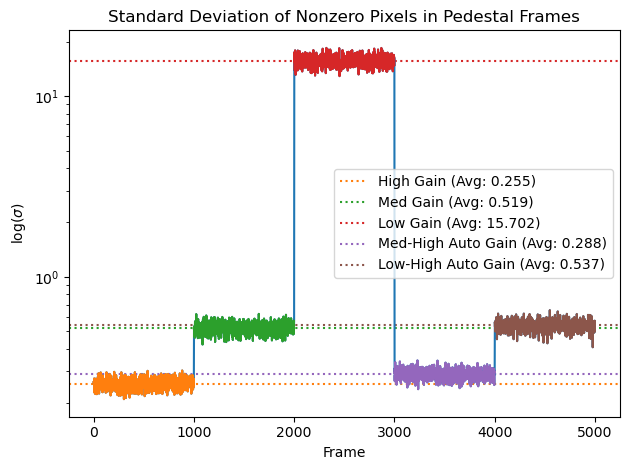

In [225]:
gain_modes = ["High", "Med", "Low", "Med-High Auto", "Low-High Auto"]

plt.plot(frame_stds)
plt.yscale('log')
plt.title("Standard Deviation of Nonzero Pixels in Pedestal Frames")
plt.ylabel("log($\sigma$)")
plt.xlabel("Frame")
for i in range(5):
    line, = plt.plot(np.arange(1000 * i, 1000 * (i+1) - 1), frame_stds[1000 * i: 1000 * (i+1) - 1])
    plt.axhline(avg_stds[i],linestyle = 'dotted', color=line.get_color(),zorder=1,label=f'{gain_modes[i]} Gain (Avg: {avg_stds[i]:.03f})')
plt.legend()
plt.tight_layout();

Events 1000-2000 are in the Med Gain range!

In [189]:
med_gain_imgs = img_raw_evts[1000:1999]

The std dev of every frame in the med gain range

In [198]:
med_gain_stds_frames = np.array([np.std(img[img > 0]) for img in med_gain_imgs])

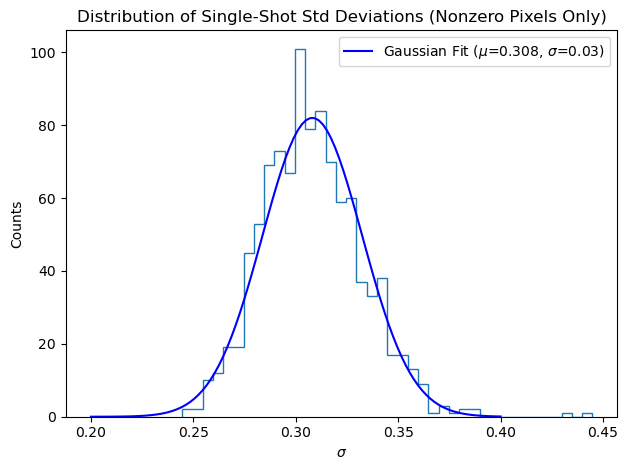

In [223]:
plt.hist(med_gain_stds_frames,bins = 40,histtype='step')
plt.title("Distribution of Single-Shot Std Deviations (Nonzero Pixels Only)")
plt.xlabel("$\sigma$")
plt.ylabel("Counts")

mu,std = norm.fit(med_gain_stds_frames)
xmin,xmax = plt.xlim()
x_axis = np.linspace(0.2,0.4,100)
fitted = norm.pdf(x_axis,mu,std)
# Plot the distribution
plt.plot(x_axis, 5 * (fitted), color='blue', label=f'Gaussian Fit ($\mu$={mu:.03f}, $\sigma$={sigma})');
plt.legend()
plt.tight_layout()

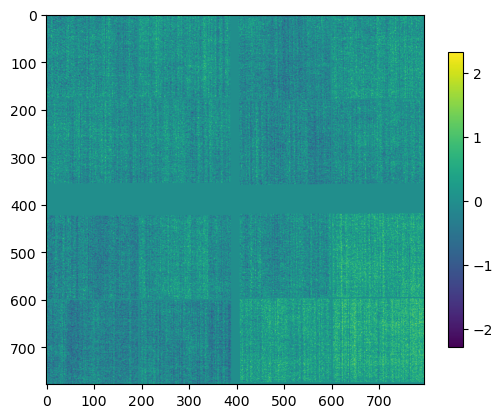

In [101]:
img_sgl = img_raw_evts[0] # Check one image
plt.imshow(np.transpose(img_sgl),cmap = 'viridis');plt.colorbar(shrink=0.8)

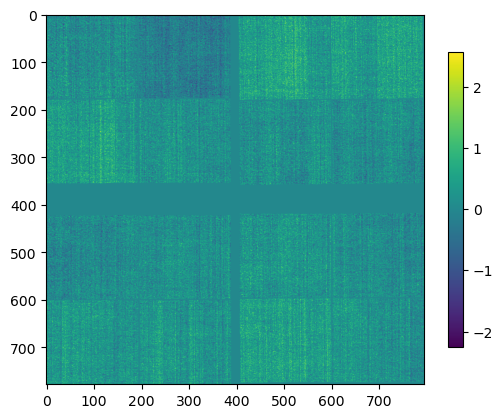

In [102]:
img_sgl = img_raw_evts[-1] # Check one image
plt.imshow(np.transpose(img_sgl),cmap = 'viridis');plt.colorbar(shrink=0.8)

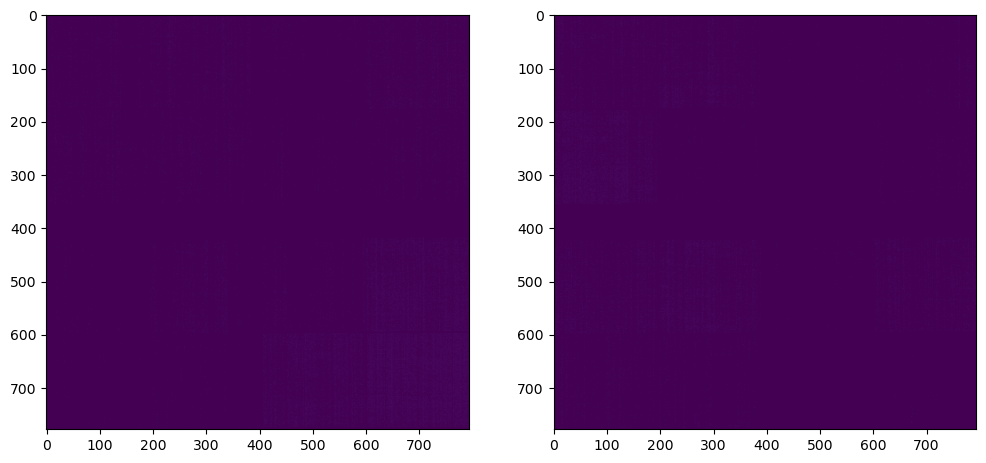

In [103]:
fig,ax = plt.subplots(1,2,figsize=(12,8))
ax = ax.flatten()
for i in range(2):
    ax[i].imshow(np.transpose(img_raw_evts[i]),cmap = 'viridis', vmin=0,vmax=50)

In [104]:
type(img_raw_evts[0])

numpy.ndarray

In [105]:
pixel_std = np.std(img_raw_evts,axis=0)

In [114]:
pixel_std_flat = np.array([np.mean(pixel_map.flatten()) for pixel_map in pixel_std]).flatten()

In [116]:
len(pixel_std_flat)

794

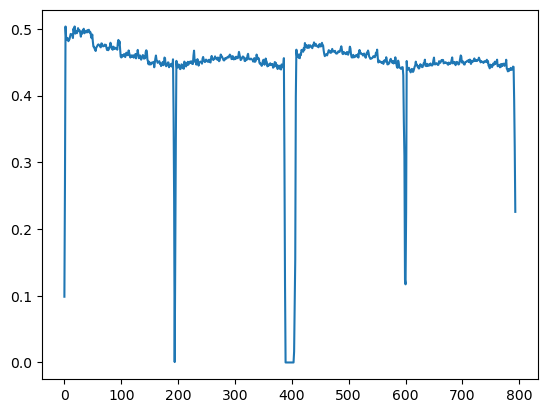

In [115]:
plt.plot(pixel_std_flat)

Text(0.5, 1.0, 'Standard Deviation of DARK ePix pixels')

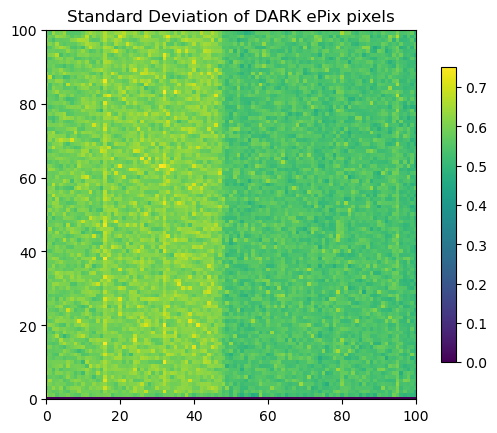

In [106]:
plt.imshow(np.transpose(pixel_std),cmap = 'viridis', vmin=0,vmax=max((np.transpose(pixel_std)[0:100,0:100]).flatten()));
plt.colorbar(shrink=0.8)
plt.xlim(0,100)
plt.ylim(0,100)
plt.title("Standard Deviation of DARK ePix pixels")

Text(0.5, 1.0, 'Standard Deviation of DARK ePix pixels (Run 125)')

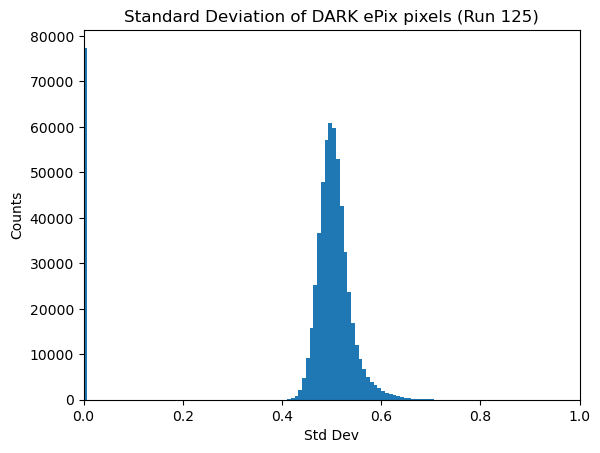

In [107]:
plt.hist(pixel_std.flatten(),bins=1000)
plt.xlim(0,1);
plt.xlabel("Std Dev")
plt.ylabel("Counts")
plt.title("Standard Deviation of DARK ePix pixels (Run 125)")

In [31]:
np.mean(pixel_std.flatten()[pixel_std.flatten() > 0])

0.33846033

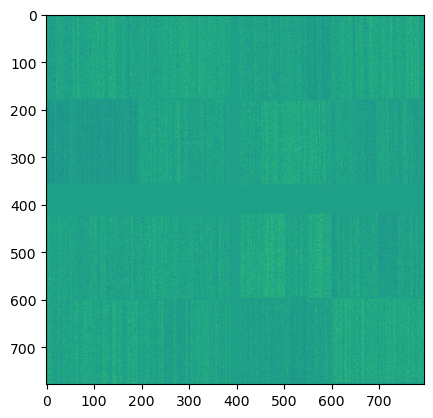

In [94]:
img_sgl = img_raw_evts[0] # Check one image
img_avg = np.mean(img_raw_evts,axis=0)
plt.imshow(img_avg.T,cmap = 'viridis');

In [56]:
noise = img_avg.flatten()[img_avg.flatten() != 0]

0.009865474 0.029004825


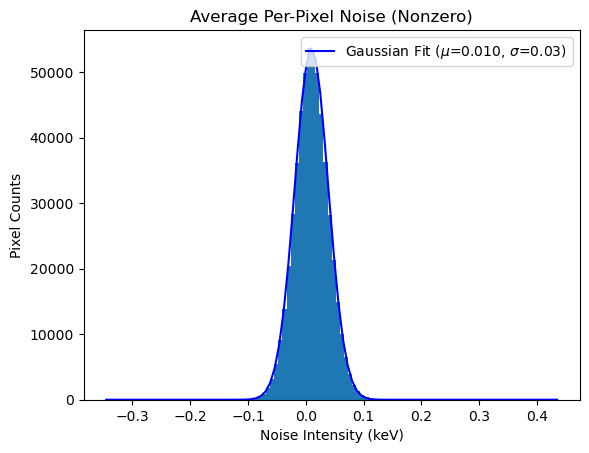

In [80]:
from scipy.stats import norm

plt.hist(noise,bins=100);
plt.title("Average Per-Pixel Noise (Nonzero)")
plt.xlabel("Noise Intensity (keV)")
plt.ylabel("Pixel Counts")

mu,std = norm.fit(noise)
print(mu, std)
xmin,xmax = plt.xlim()
x_axis = np.linspace(xmin,xmax,100)
fitted = norm.pdf(x_axis,mu,std)
# Plot the distribution
plt.plot(x_axis, 3900 * (fitted), color='blue', label=f'Gaussian Fit ($\mu$={mu:.03f}, $\sigma$={sigma})');
plt.legend()